# Spatial, Ensemble, and Temporal Means Correlation Heatmap Plots
This notebook walks through generating correlation heatmap plots using Spatial, Ensemble, and Temporal means, assuming that you have monthly merged netCDF data that is generated by 'monthly_merged_data_generation.py'

- Correlation Method can be changed under the import statement, code must be re-run
- File paths should be set underneath the correlation method chunk

In [1]:
# import necessary packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import os

# set figure resolution
plt.rcParams['figure.dpi'] = 300

# set nan values in plot to grey
sns.set(rc={'axes.facecolor':'grey'})

In [2]:
'''Comment out the type of correlation that you do not wish to use
'''
# spearman correlation
correlation_method = 'spearman'

# pearson correlation
# correlation_method = 'pearson'

In [3]:
'''Set file paths
'''
# file path to monthly merged data folder (change to your path)
folder_path = 'data/netCDF/monthly/'

# figures folder (change to your path)
figures_path = 'figures/'

# normalize paths
figures_path_norm = os.path.normpath(figures_path)

# Data Loading, pre-processing, and Helper Functions

In [5]:
'''Load the monthly merged data into a dictionary
'''
# Normalize the path to handle both slashes and backslashes
normalized_path = os.path.normpath(folder_path)

# list of all direct file paths in netCDF folder
file_list = [os.path.join(normalized_path, file_name) for file_name in os.listdir(folder_path)]

# Create an empty dictionary to store the DataFrames
dataframes = {}

# iterate over all files in the file list
for file_path in file_list:
    # status message
    print(f"Currently Processing: {os.path.basename(file_path)}")

    # extract the current region from the file name
    current_region = '_'.join(os.path.basename(file_path).split('_')[0:-2])

    # extract the current model from the file name
    current_model = os.path.basename(file_path).split('_')[-2]
    try:
        # Load the NetCDF file, convert to DataFrame, and store in the dictionary
        dataframes[(current_region, current_model)] = xr.open_mfdataset(file_path).to_dataframe().reset_index()

    # error handling
    except FileNotFoundError:
        print(f"Warning: File not found: {file_path}")
    except Exception as e:  # Catch other potential errors
        print(f"Error loading file {file_path}: {e}")

Currently Processing: west_africa_CMCC_merged.nc
Currently Processing: southern_africa_CMCC_merged.nc


In [ ]:
"""Check if all regions and models of interest are loaded in properly
"""
# Define region and model list, based on regions and models of interest
regions = ['south_sudan', 'eastern_east_africa', 'eastern_ukraine', 'southern_africa', 'west_africa', 'sri_lanka', 'lake_victoria_basin']
models = ['CanESM5', 'CCSM4', 'CESM1', 'GEM5', 'GFDL', 'NASA', 'NCEP', 'CMCC', 'DWD', 'ECMWF', 'METEO', 'JMA']

# Create all expected dataframe keys
expected_keys = [(region, model) for region in regions for model in models]

# Check if all expected keys are present in the dataframes dictionary
all_dataframes_loaded = all(key in dataframes for key in expected_keys)

# Print a single message indicating overall success or failure
if all_dataframes_loaded:
    print("All DataFrames loaded successfully!")
else:
    missing_keys = [key for key in expected_keys if key not in dataframes]
    for region, model in missing_keys:
        print(f"Warning: DataFrame not found for region '{region}' and model '{model}'")

In [7]:
# Adding Dry Masking, months chosen from dry_masking.py
dry_mask_months = {'south_sudan': [1,2,12],
                   'eastern_east_africa': [1,2],
                   'southern_africa': [5,6,7,8,9],
                   'west_africa': [1,2,3,11,12]}

In [8]:
'''Helper function for Spatial/Ensemble/Temporal Mean Heatmap
'''
def draw_heatmap(*args, **kwargs):
    '''Helper function for drawing Spatial/Ensemble/Temporal Means heatmaps

    Note:
    Values bounded from -0.7 to 0.7, Red to Blue color palette
    '''
    # access the dataframe that is passed into the function
    data = kwargs.pop('data')

    # pivot data, index is month, columns is lead time, values is correlation
    d = data.pivot(index=args[1], columns=args[0], values=args[2])

    # define a heatmap with pivoted data, value bounds, and colors
    sns.heatmap(d, **kwargs, vmin=-0.7, vmax=0.7,
                cmap=sns.color_palette('vlag', 12),
                linewidths=0.1, linecolor='black')

    # Heatmap label settings
    plt.xticks(np.arange(0.5, 12.5, 1))  # Set xticks explicitly
    plt.gca().set_xticklabels(np.arange(0.5, 12.5, 1))  # Set xticklabels
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    plt.gca().invert_yaxis()
    plt.xticks(rotation=45)
    plt.tick_params(axis='both', which='major', pad=0) # reduce padding of axis labels

# Plotting Correlation for Ensemble Mean

In [9]:
'''This code chunk calculates the ensemble means of each model and region,
and stores dataframes in a dictionary for plotting
'''
# Create empty dictionary to store results for ensemble mean
ensemble_means_corr_dict = {}

# define years of interest
start_year = 1993
end_year = 2024

# iterate over all items in dataframes dictionary
for df_key, df in dataframes.items():

    # drop all na values in the dataframe (i.e. CHIRPS measuring ocean areas)
    df.dropna(inplace=True)

    # subset to years of interest
    df_filtered = df[df['time'].dt.year.between(start_year, end_year)]

    # Calculate ensemble mean
    ensemble_means = (df_filtered
                        .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                        .mean().reset_index())

    # Extract months
    ensemble_means['month'] = ensemble_means['time'].dt.month

    # Calculate the spearmean correlation between predicted and actual precip
    ensemble_means_corr = (ensemble_means
                            .groupby(['month', 'lead_time'])[['predicted_precip', 'precip']].corr(method=correlation_method)
                            .iloc[0::2, -1].droplevel(-1).reset_index())  # Corrected droplevel

    # rename precip to corr for consistency
    ensemble_means_corr.rename(columns={'precip': 'corr'}, inplace=True)

    # Store results in ensemble means dictionary
    ensemble_means_corr_dict[df_key] = ensemble_means_corr

In [10]:
# Combine all ensemble mean correlations dataframes from dictionary into one DataFrame
ensemble_corr = pd.concat(ensemble_means_corr_dict.values(), keys=ensemble_means_corr_dict.keys(), names=['region', 'model'])

# reset index and drop levels of the combined dataframe for plotting
ensemble_corr.reset_index(inplace=True)
ensemble_corr.drop('level_2', axis=1, inplace=True)

In [11]:
# Create a copy for dry-masked data
ensemble_corr_dm = ensemble_corr.copy()

# Create a list to store rows to mask
rows_to_mask = []

# Iterate through the dry_mask_months dictionary
for region, months in dry_mask_months.items():
    # Find matching rows in ensemble_corr_dm (using the copy)
    mask = (ensemble_corr_dm['region'] == region) & (ensemble_corr_dm['month'].isin(months))
    # Append matching row indices to the list
    rows_to_mask.extend(ensemble_corr_dm[mask].index)

# Set 'corr' to NaN for the selected rows in ensemble_corr_dm
ensemble_corr_dm.loc[rows_to_mask, 'corr'] = np.nan

FileNotFoundError: [Errno 2] No such file or directory: 'figures/spearman_ensemble_means_corr.png'

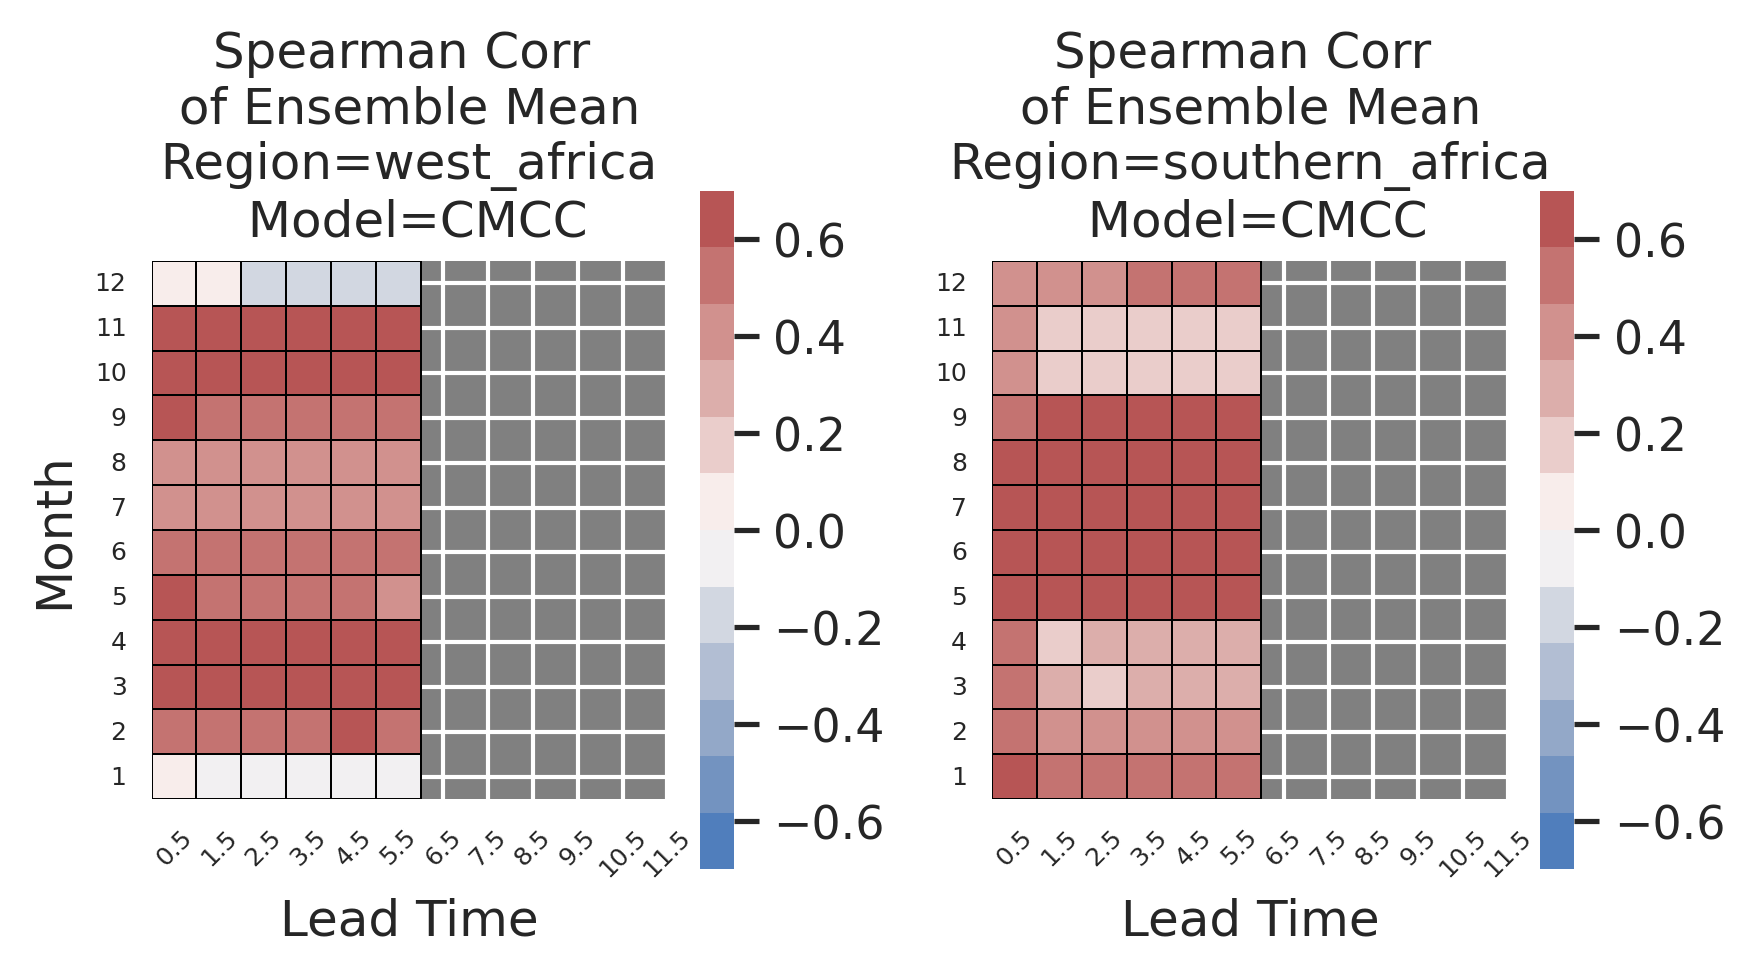

In [13]:
'''Plot Ensemble Means Correlation Heatmap
'''
# create facetGrid
fg = sns.FacetGrid(ensemble_corr, col='region', row='model', sharex=False, sharey=False)

# draw heatmaps for each region and season on the facetGrid
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# set titles
fg.set_titles(f'{correlation_method.capitalize()} Corr \n of Ensemble Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'{correlation_method}_ensemble_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/dry_masked_spearman_ensemble_means_corr.png'

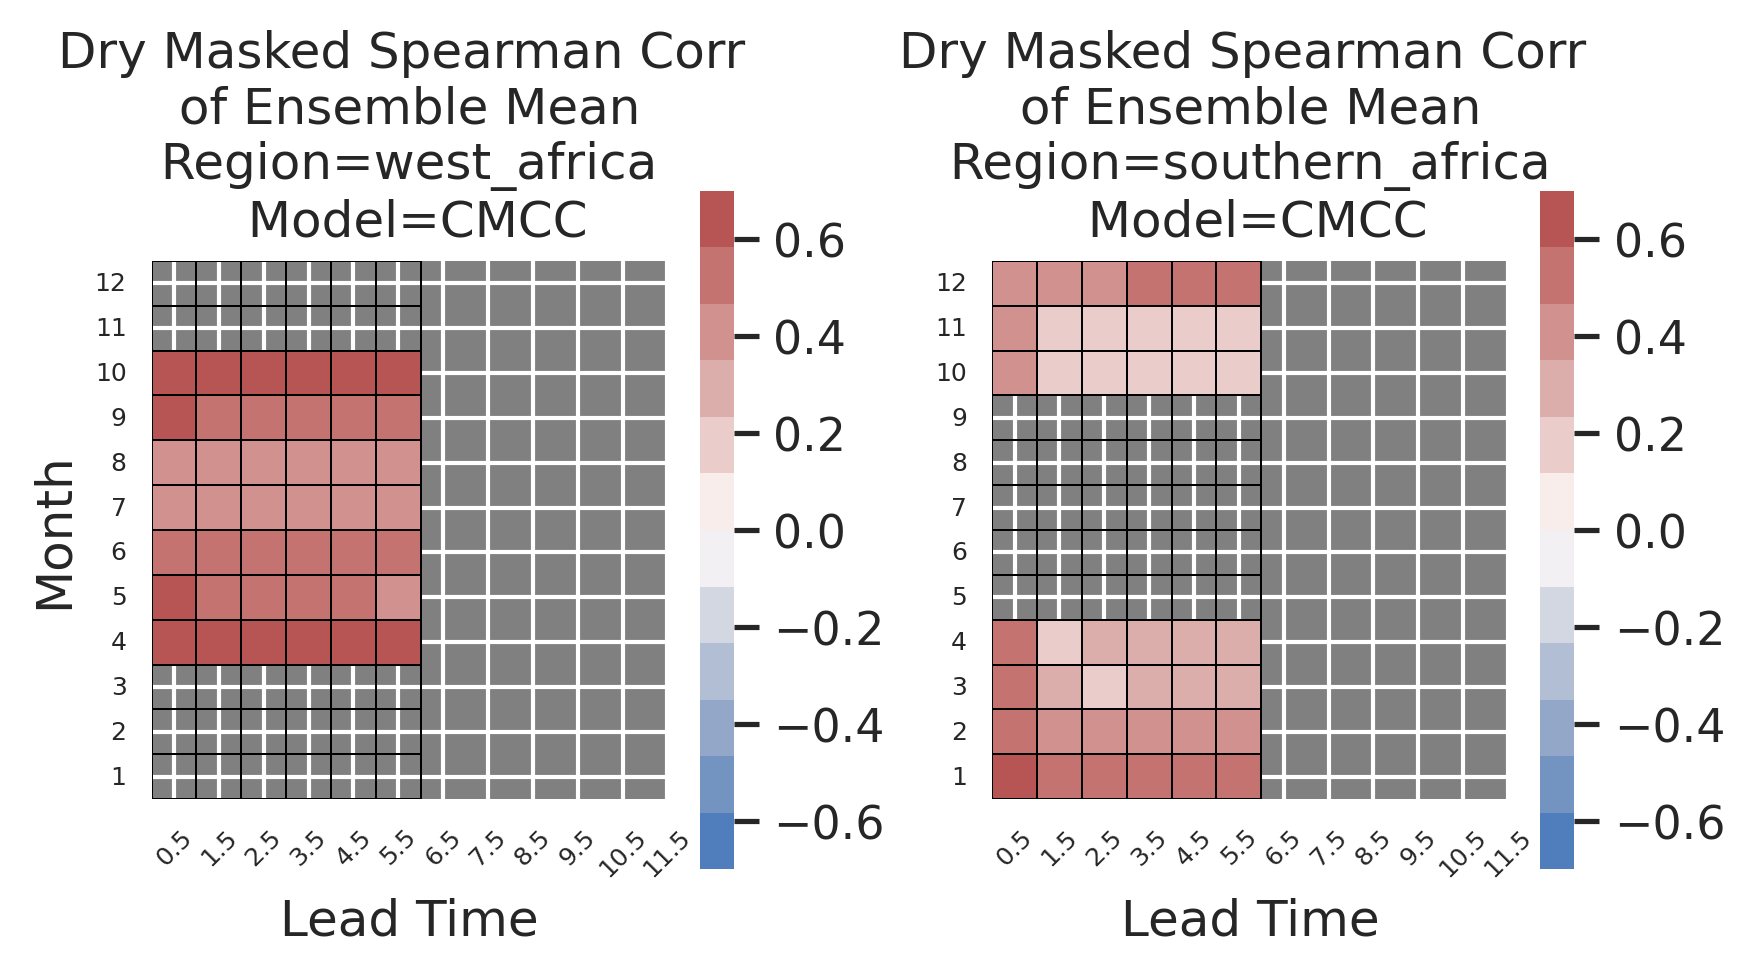

In [14]:
'''Plot Dry Masked Ensemble Means Correlation Heatmap
'''
# create facetGrid
fg = sns.FacetGrid(ensemble_corr_dm, col='region', row='model', sharex=False, sharey=False)

# draw heatmaps for each region and season on the facetGrid
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# set titles
fg.set_titles(f'Dry Masked {correlation_method.capitalize()} Corr \n of Ensemble Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'dry_masked_{correlation_method}_ensemble_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()

# Plotting Correlation for Spatial Mean

In [15]:
'''This code chunk calculates the ensemble means of each model and region,
then spatial means, and stores dataframes in a dictionary for plotting
'''

# Create empty dictionaries to store results for spatial means
spatial_means_corr_dict = {}

# define years of interest
start_year = 1993
end_year = 2024

# iterate over all items in dataframes dictionary
for df_key, df in dataframes.items():

    # drop all na values in the dataframe (i.e. CHIRPS measuring ocean areas)
    df.dropna(inplace=True)

    # subset to years of interest
    df_filtered = df[df['time'].dt.year.between(start_year, end_year)]

    # Calculate ensemble mean
    ensemble_means = (df_filtered
                        .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                        .mean().reset_index())

    # Calculate spatial means
    spatial_means = (ensemble_means  # Use the ensemble_means DataFrame
                        .groupby(['time', 'lead_time'])[['predicted_precip', 'precip']]
                        .mean().reset_index())

    # Extract months
    spatial_means['month'] = spatial_means['time'].dt.month

    # Calculate correlation
    spatial_means_corr = (spatial_means
                            .groupby(['month', 'lead_time'])[['predicted_precip', 'precip']].corr(method=correlation_method)
                            .iloc[0::2, -1].droplevel(-1).reset_index()) #Corrected droplevel

    # rename for consistency
    spatial_means_corr.rename(columns={'precip': 'corr'}, inplace=True)

    # Store results in dictionary
    spatial_means_corr_dict[df_key] = spatial_means_corr

In [16]:
# Combine all correlations into one DataFrame
spatial_corr = pd.concat(spatial_means_corr_dict.values(), keys=spatial_means_corr_dict.keys(), names=['region', 'model'])

# reset index for plotting, drop levels
spatial_corr.reset_index(inplace=True)
spatial_corr.drop('level_2', axis=1, inplace=True)

In [17]:
# Create a copy for dry-masked data
spatial_corr_dm = spatial_corr.copy()

# Create a list to store rows to mask
rows_to_mask = []

# Iterate through the dry_mask_months dictionary
for region, months in dry_mask_months.items():
    # Find matching rows in spatial_corr_dm (using the copy)
    mask = (spatial_corr['region'] == region) & (spatial_corr_dm['month'].isin(months))
    # Append matching row indices to the list
    rows_to_mask.extend(spatial_corr_dm[mask].index)

# Set 'corr' to NaN for the selected rows in spatial_corr_dm
spatial_corr_dm.loc[rows_to_mask, 'corr'] = np.nan

FileNotFoundError: [Errno 2] No such file or directory: 'figures/dry_masked_spearman_spatial_means_corr.png'

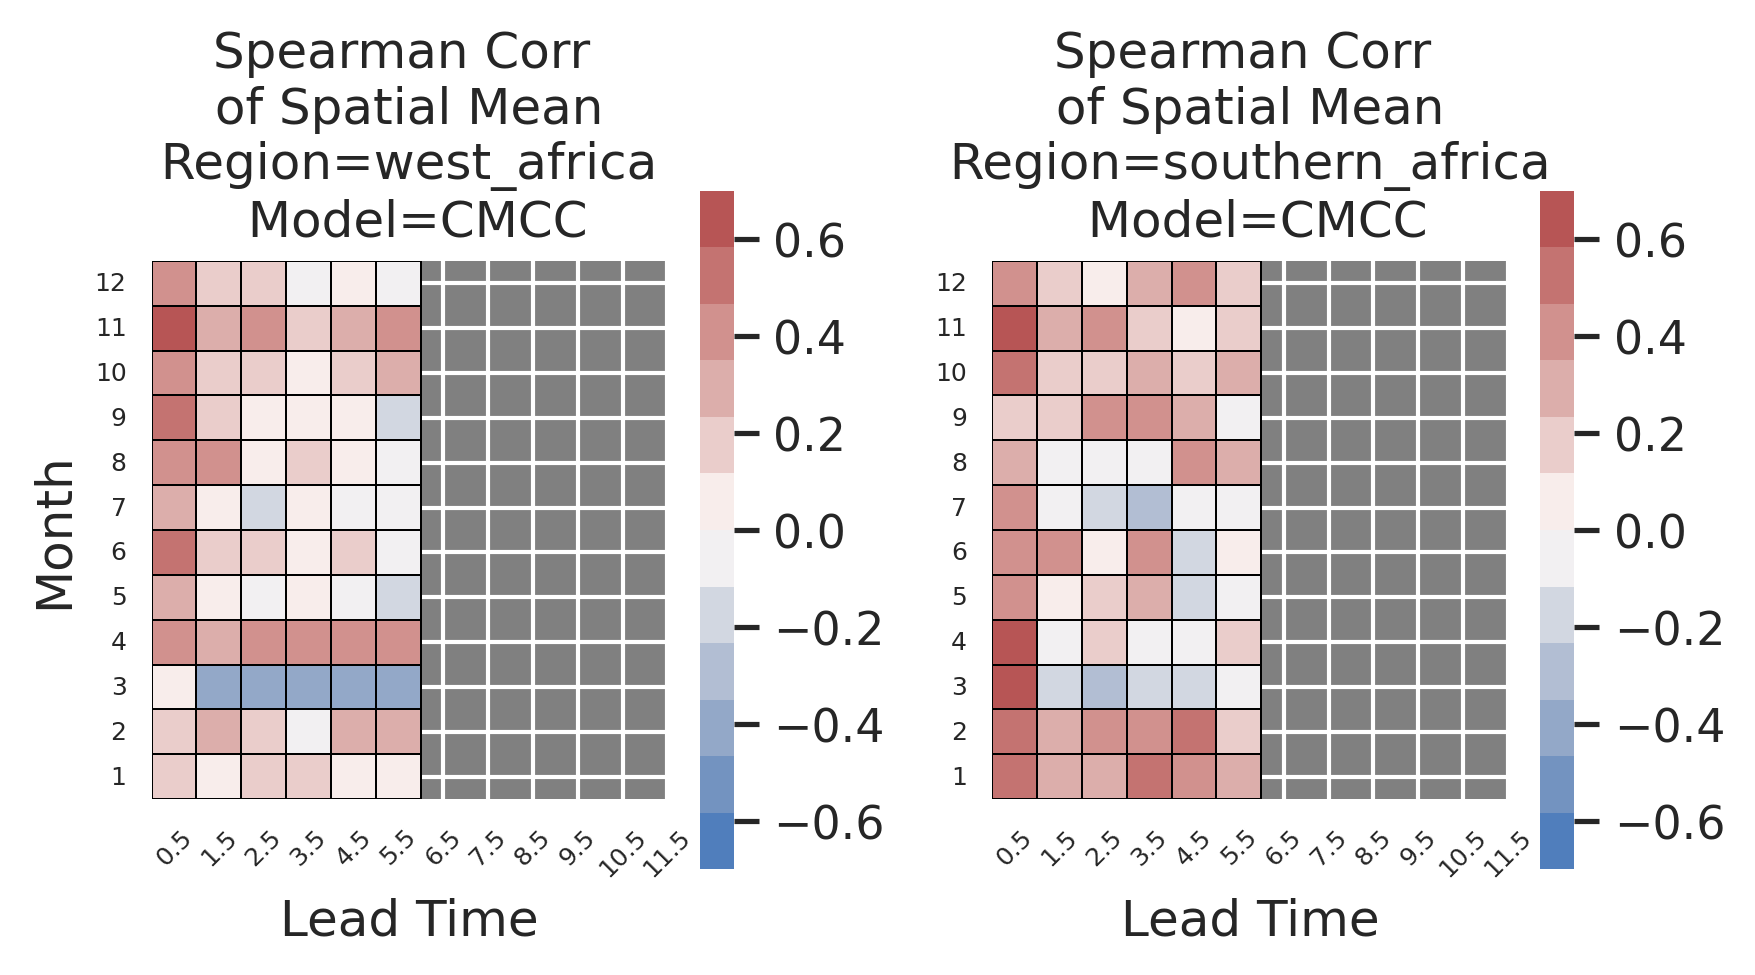

In [19]:
'''Plot Spatial Means Correlation Heatmap
'''

# define a facetGrid, draw heatmaps on the grid
fg = sns.FacetGrid(spatial_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# heatmap titles
fg.set_titles(f'{correlation_method.capitalize()} Corr \n of Spatial Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'dry_masked_{correlation_method}_spatial_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/spearman_spatial_means_corr.png'

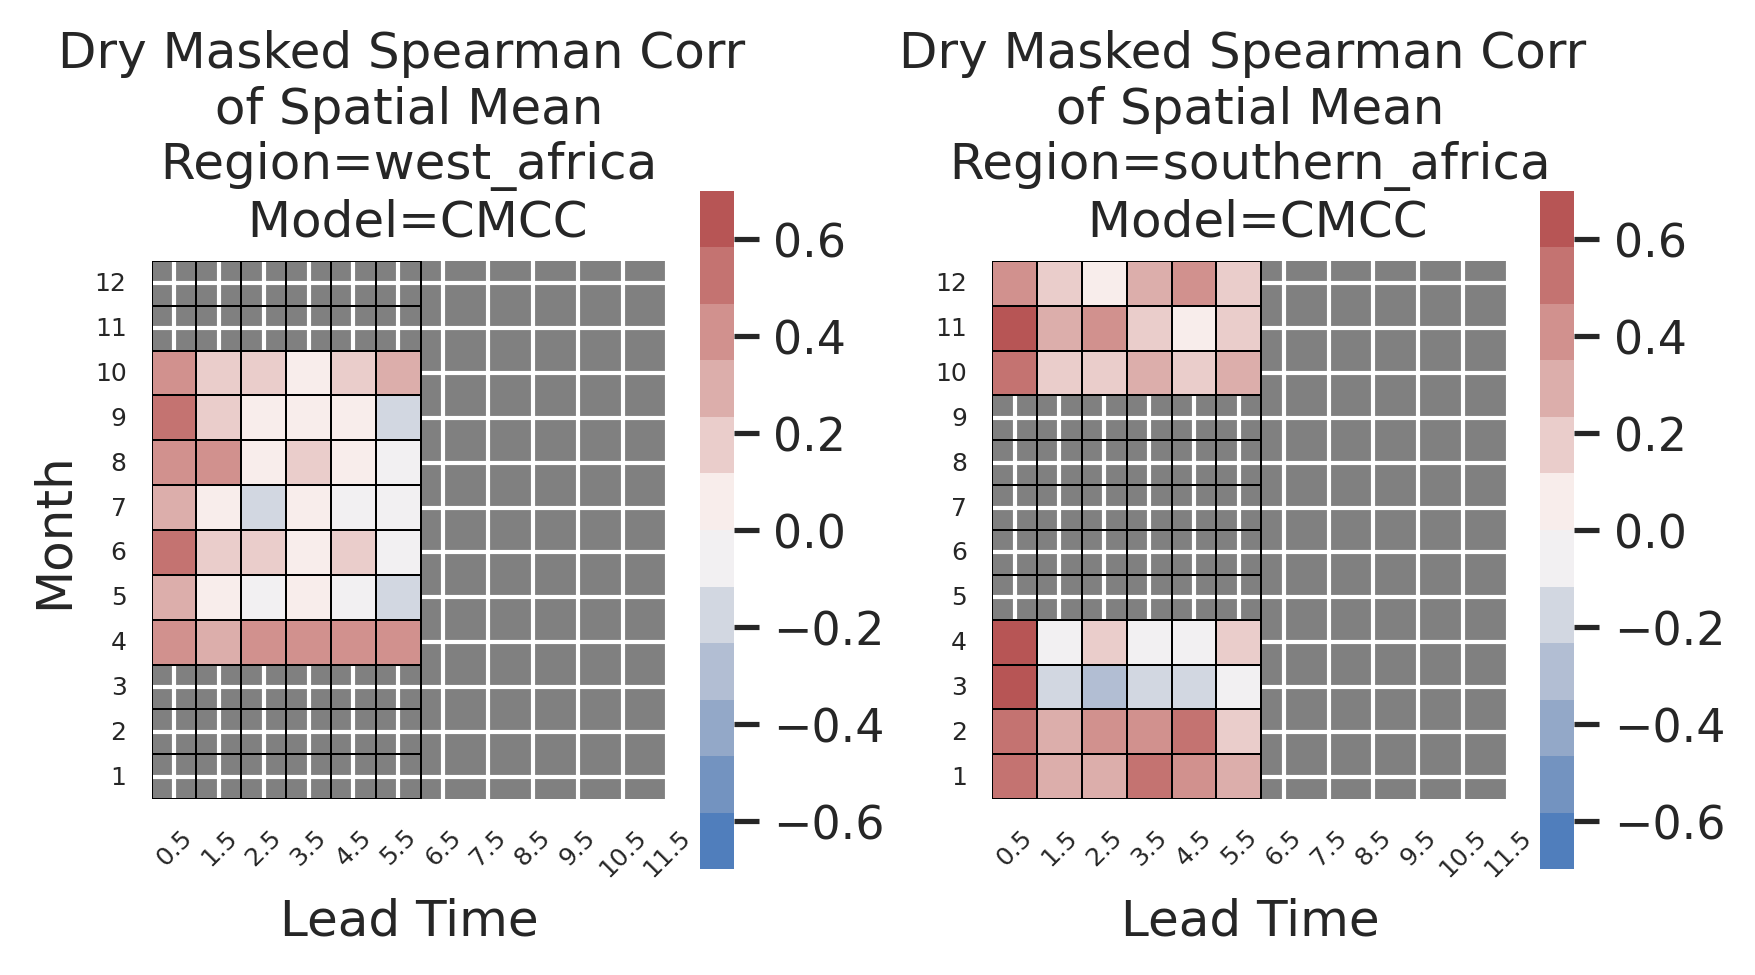

In [20]:
'''Plot Dry Masked Spatial Means Correlation Heatmap
'''

# define a facetgrid, draw heatmaps on the grid
fg = sns.FacetGrid(spatial_corr_dm, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# heatmap titles
fg.set_titles(f'Dry Masked {correlation_method.capitalize()} Corr \n of Spatial Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'{correlation_method}_spatial_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()

# Plotting Spearman Correlation Heatmaps for Temporal Mean

In [21]:
'''This code chunk calculates the ensemble means of each model and region, then
the temporal means, and stores dataframes in a dictionary for plotting
'''
# Create empty dictionaries to store results for temporal means
temporal_means_corr_dict = {}

# define years of interest
start_year = 1993
end_year = 2024

# iterate over all items in dataframes dictionary
for df_key, df in dataframes.items():

    # drop all na values in the dataframe (i.e. CHIRPS measuring ocean areas)
    df.dropna(inplace=True)

    # subset to years of interest
    df_filtered = df[df['time'].dt.year.between(start_year, end_year)]

    # Calculate ensemble mean (reuse from previous examples)
    ensemble_means = (df_filtered
                        .groupby(['time', 'lead_time', 'latitude', 'longitude'])[['predicted_precip', 'precip']]
                        .mean().reset_index())
    ensemble_means['month'] = ensemble_means['time'].dt.month


    # Calculate temporal means
    temporal_means = (ensemble_means
                        .groupby(['latitude', 'longitude', 'month', 'lead_time'])[['predicted_precip', 'precip']]
                        .mean().reset_index())

    # Calculate correlation
    temporal_means_corr = (temporal_means
                            .groupby(['month', 'lead_time'])[['predicted_precip', 'precip']].corr(method=correlation_method)
                            .iloc[0::2, -1].droplevel(-1).reset_index()) #Corrected droplevel

    # rename for consistency
    temporal_means_corr.rename(columns={'precip': 'corr'}, inplace=True)

    # Store results in dictionary
    temporal_means_corr_dict[df_key] = temporal_means_corr

In [22]:
# Combine all correlations into one DataFrame
temporal_corr = pd.concat(temporal_means_corr_dict.values(), keys=temporal_means_corr_dict.keys(), names=['region', 'model'])

# reset index for plotting, drop levels
temporal_corr.reset_index(inplace=True)
temporal_corr.drop('level_2', axis=1, inplace=True)

In [23]:
# Makes copy of temporal corr for dry masking
temporal_means_dm = temporal_corr.copy()

# Create a list to store rows to mask
rows_to_mask = []

# Iterate through the dry_mask_months dictionary
for region, months in dry_mask_months.items():
    # Find matching rows in spatial_corr_dm (using the copy)
    mask = (temporal_corr['region'] == region) & (temporal_means_dm['month'].isin(months))
    # Append matching row indices to the list
    rows_to_mask.extend(temporal_means_dm[mask].index)

# Set 'corr' to NaN for the selected rows in spatial_corr_dm
temporal_means_dm.loc[rows_to_mask, 'corr'] = np.nan

FileNotFoundError: [Errno 2] No such file or directory: 'figures/spearman_temporal_means_corr.png'

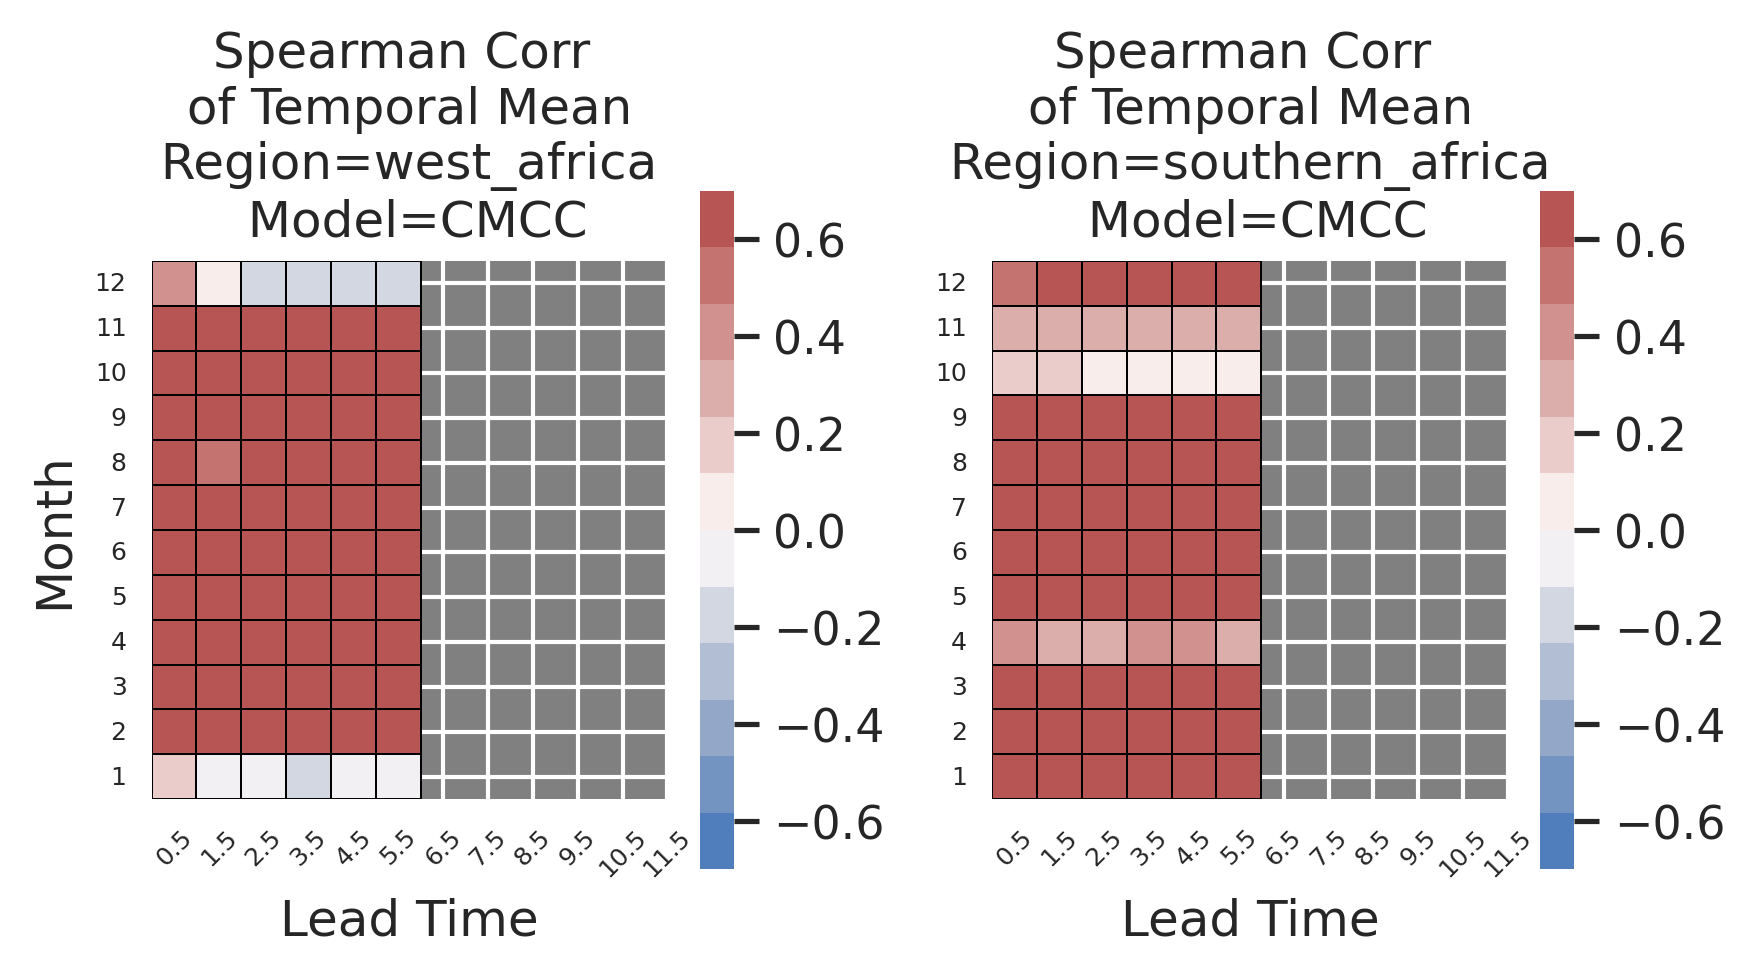

In [24]:
# create facetGrid, plot heatmaps on grid
fg = sns.FacetGrid(temporal_corr, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# heatmap titles
fg.set_titles(f'{correlation_method.capitalize()} Corr \n of Temporal Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'{correlation_method}_temporal_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'figures/dry_masked_spearman_temporal_means_corr.png'

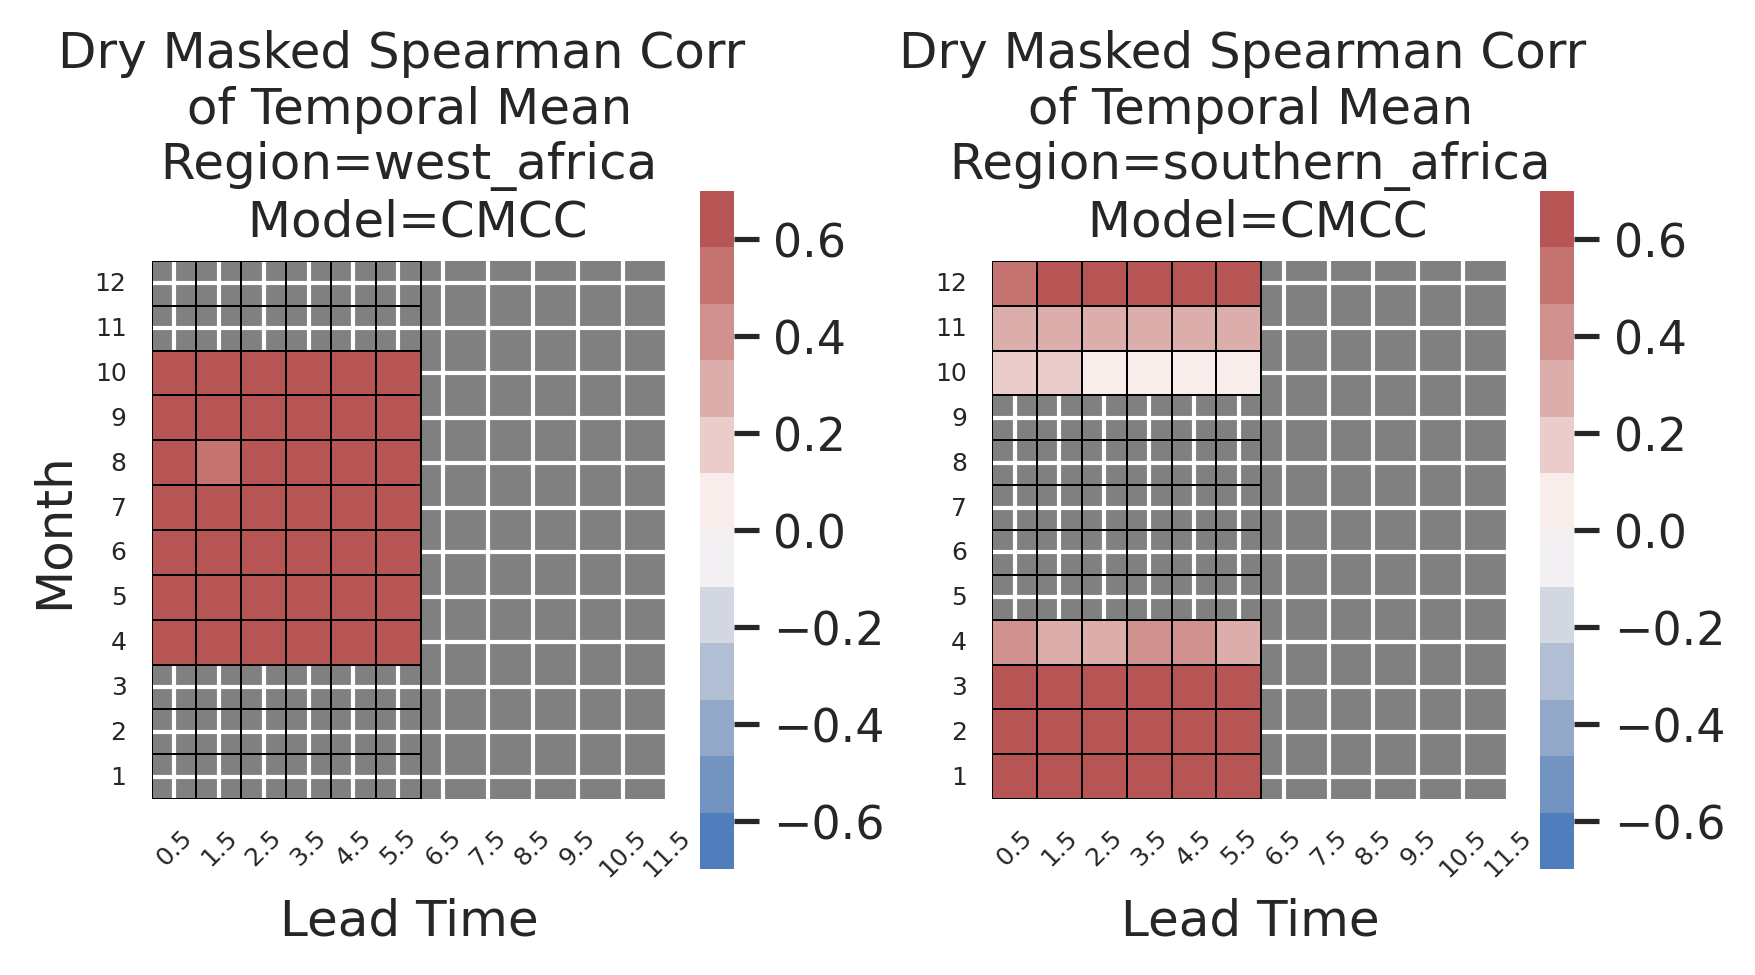

In [25]:
# create facetGrid, plot heatmaps on grid
fg = sns.FacetGrid(temporal_means_dm, col='region', row='model', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead_time', 'month', 'corr', square = True)

# heatmap titles
fg.set_titles(f'Dry Masked {correlation_method.capitalize()} Corr \n of Temporal Mean \n Region={{col_name}} \n Model={{row_name}}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")

# save figure
save_path = os.path.join(figures_path_norm, f'dry_masked_{correlation_method}_temporal_means_corr.png')
fg.savefig(save_path)

# close for efficiency
plt.close()